# **🎓 STUDENTS ACADEMIC PERFORMANCE 2025**


**Step 1: Import Libraries**

In [26]:
#Impoort core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set visualization style
sns.set_style("whitegrid")

**Step 2: Upload Dataset**

In [27]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/🎓 STUDENTS ACADEMIC PERFORMANCE 2025/Students_Data.csv")

#Display the first 5 Row
print("--- Head of the Dataset ---")
df.head()

--- Head of the Dataset ---


,Gender,Ethnicity,Parental Education,Lunch Type,Test Preparation Course,Maths Score,Reading Score,Writing Score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 3: Basic Data Understandin**

In [29]:
# Get information about columes, data types, and non-null values
print("\n--- Dataset Info --- ")
df.info()


--- Dataset Info --- 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Gender                   1000 non-null   object
 1   Ethnicity                1000 non-null   object
 2   Parental Education       1000 non-null   object
 3   Lunch Type               1000 non-null   object
 4   Test Preparation Course  1000 non-null   object
 5   Maths Score              1000 non-null   int64 
 6   Reading Score            1000 non-null   int64 
 7   Writing Score            1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [30]:
#Get summary statistics for numerical columns
print("\n--- Descriptive Statistics  ---")
df.describe()


--- Descriptive Statistics  ---


,Maths Score,Reading Score,Writing Score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [31]:
df.isnull().sum()

,0
Gender,0
Ethnicity,0
Parental Education,0
Lunch Type,0
Test Preparation Course,0
Maths Score,0
Reading Score,0
Writing Score,0


# **Identifying and Performing Case Studies**


**Case Study 1: Top Performing Students**

In [32]:
df["Total_Marks"] = df["Maths Score"] + df["Reading Score"] + df["Writing Score"]

top_students = df.sort_values("Total_Marks", ascending=False).head(10)
top_students

,Gender,Ethnicity,Parental Education,Lunch Type,Test Preparation Course,Maths Score,Reading Score,Writing Score,Total_Marks
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
114,female,group E,bachelor's degree,standard,completed,99,100,100,299
712,female,group D,some college,standard,none,98,100,99,297
179,female,group D,some high school,standard,completed,97,100,100,297
165,female,group C,bachelor's degree,standard,completed,96,100,100,296
625,male,group D,some college,standard,completed,100,97,99,296
685,female,group E,master's degree,standard,completed,94,99,100,293
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,293


#**Case Study 2: Gender Performance Comparison**

In [33]:
df.groupby("Gender")["Total_Marks"].mean()

,Total_Marks
Gender,
female,208.708494
male,197.512448


**📊 Visualization:** Bar Chart

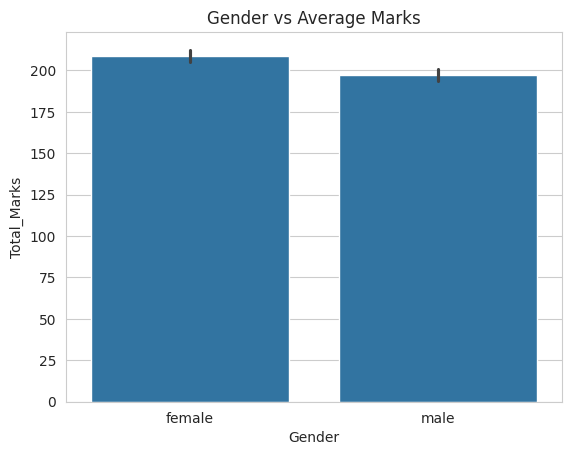

In [34]:
sns.barplot (x="Gender", y="Total_Marks", data=df)
plt.title("Gender vs Average Marks")
plt.show()

**📊 Visualization:** Pie Chart

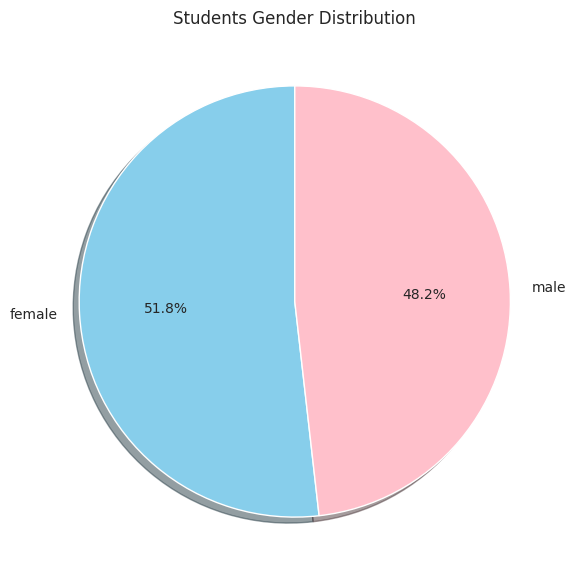

In [35]:
plt.figure(figsize=(7,7))

colors = ["skyblue","pink"]

plt.pie(df["Gender"].value_counts(),
        labels=df["Gender"].value_counts().index,
        autopct='%1.1f%%',
        colors=colors,
        shadow=True,
        startangle=90)

plt.title("Students Gender Distribution")

plt.show()


#**Case Study 3: Parental Education Impact**

**Problem**:-
*Does parental education level affect student performance?* *italicized text*

Parental Education
associate's degree    208.707207
bachelor's degree     215.771186
high school           189.290816
master's degree       220.796610
some college          205.429204
some high school      195.324022
Name: Total_Marks, dtype: float64


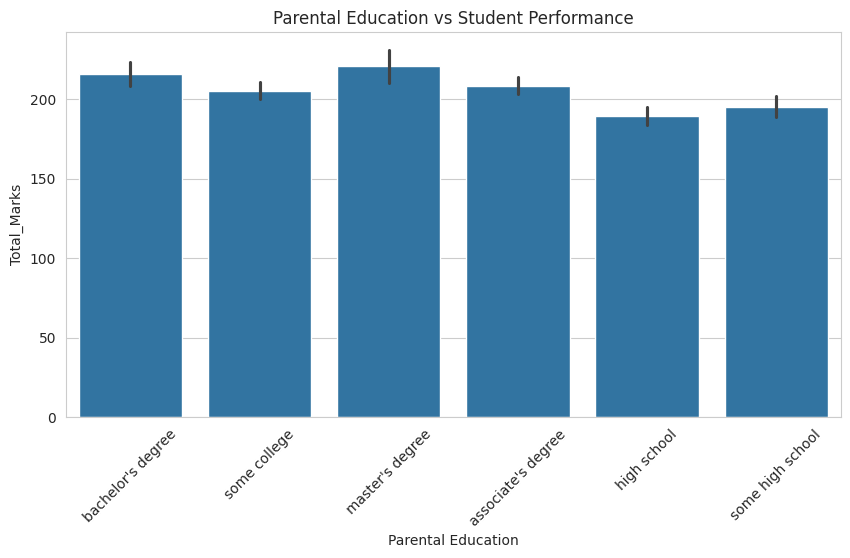

In [36]:
parent_perf = df.groupby("Parental Education")["Total_Marks"].mean()

print(parent_perf)

plt.figure(figsize=(10,5))

sns.barplot(x="Parental Education", y="Total_Marks", data=df)

plt.xticks(rotation=45)

plt.title("Parental Education vs Student Performance")

plt.show()

# **Case Study 4: Lunch Type Effect on Scores**

**Problem**:-
*Do students with standard lunch perform better than free lunch students?*

Lunch Type
free/reduced    186.597183
standard        212.511628
Name: Total_Marks, dtype: float64


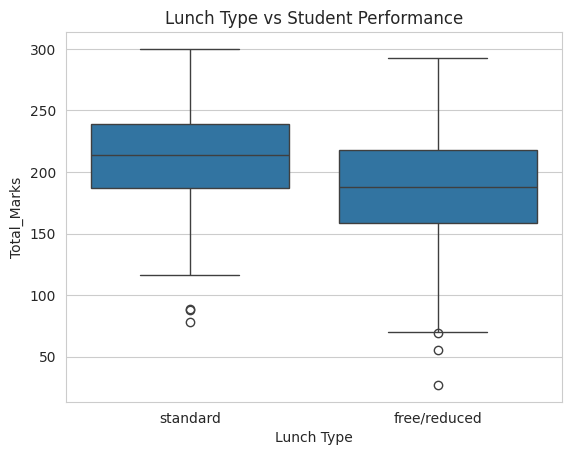

In [37]:
lunch_perf = df.groupby("Lunch Type")["Total_Marks"].mean()

print(lunch_perf)

sns.boxplot(x="Lunch Type", y="Total_Marks", data=df)

plt.title("Lunch Type vs Student Performance")

plt.show()

# **Case Study 5: Test Preparation Course Impact**

**Problem**:-
*Does completing the test preparation course improve scores?*

Test Preparation Course
completed    218.008380
none         195.116822
Name: Total_Marks, dtype: float64


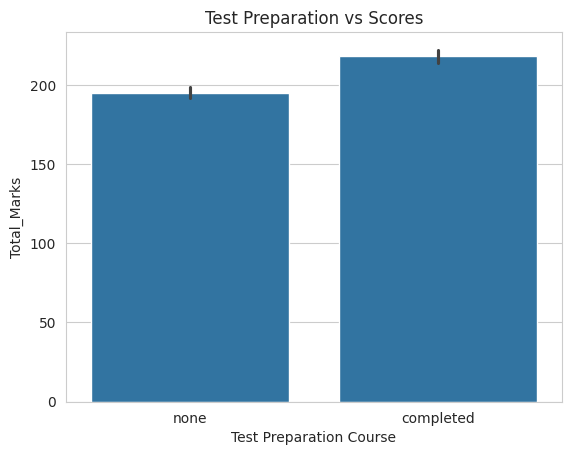

In [38]:
prep_perf = df.groupby("Test Preparation Course")["Total_Marks"].mean()

print(prep_perf)

sns.barplot(x="Test Preparation Course", y="Total_Marks", data=df)

plt.title("Test Preparation vs Scores")

plt.show()

# **Case Study 6: Test Preparation Course Impact**

**Problem**:-
*Which subject has **the highest performance?***

Maths Score      66.089
Reading Score    69.169
Writing Score    68.054
dtype: float64


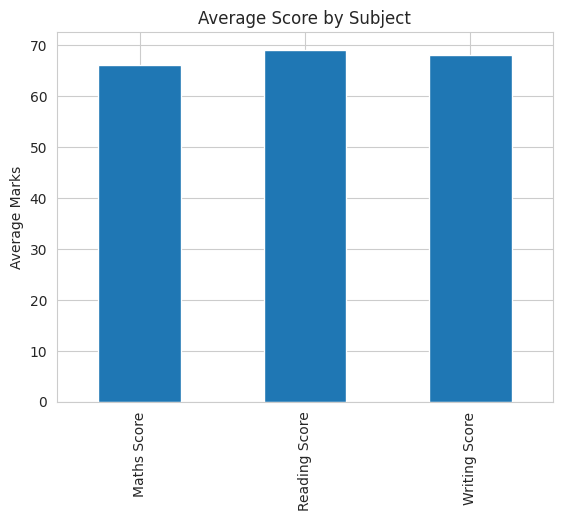

In [39]:
subjects = df[["Maths Score","Reading Score","Writing Score"]].mean()

print(subjects)

subjects.plot(kind="bar")

plt.title("Average Score by Subject")

plt.ylabel("Average Marks")

plt.show()

# **Case Study 7: Correlation Between Subjects**

**Problem:-**
*Are **maths, reading, and writing scores related?***

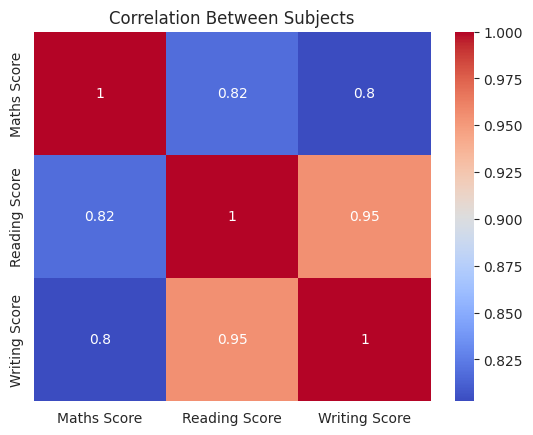

In [40]:
corr = df[["Maths Score","Reading Score","Writing Score"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Between Subjects")

plt.show()

# **Case Study 8: Ethnicity vs Academic Performance**

**Problem:-**
*Does **student ethnicity group affect exam scores?***

           Maths Score  Reading Score  Writing Score
Ethnicity                                           
group A      61.629213      64.674157      62.674157
group B      63.452632      67.352632      65.600000
group C      64.463950      69.103448      67.827586
group D      67.362595      70.030534      70.145038
group E      73.821429      73.028571      71.407143


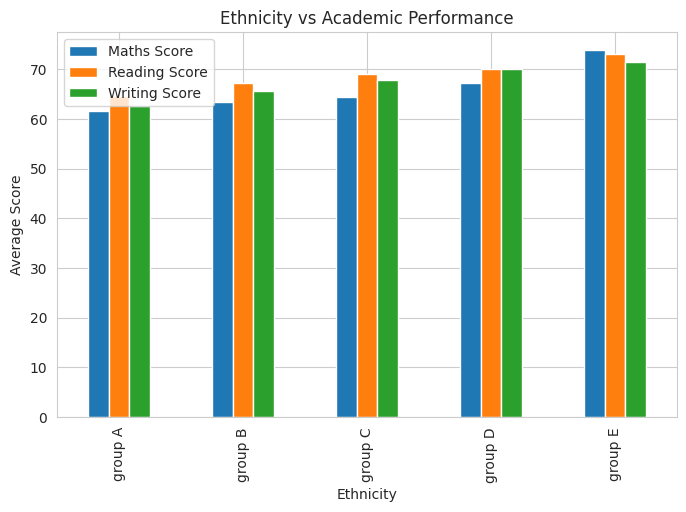

In [41]:
ethnicity_perf = df.groupby("Ethnicity")[["Maths Score","Reading Score","Writing Score"]].mean()

print(ethnicity_perf)


ethnicity_perf.plot(kind="bar", figsize=(8,5))

plt.title("Ethnicity vs Academic Performance")
plt.ylabel("Average Score")

plt.show()

# Implementing Interactive Visualizations & KPIs

# KPI Development
🎯 Important KPIs
| KPI             | Meaning             |
| --------------- | ------------------- |
| Total Students  | Total count         |
| Average Marks   | Overall performance |
| Pass Percentage | % students passed   |
| Topper Score    | Highest marks       |


In [42]:
total_students = len(df)
avg_math = df["Maths Score"].mean()     #average of math score
avg_read = df["Reading Score"].mean()   #average of reading score
avg_write = df["Writing Score"].mean()  #average of writing score
avg_marks = df["Total_Marks"].mean()    #average of total marks
top_score = df["Total_Marks"].max()
pass_percentage = (df[df["Total_Marks"] > 120].shape[0] / total_students) * 100

print("Total Students:", total_students)
print("Average Maths Score:", avg_math)
print("Average Reading Score:", avg_read)
print("Average Writing Score:", avg_write)
print("Average Marks:", avg_marks)
print("Top Score:", top_score)
print("Pass %:", pass_percentage)

Total Students: 1000
Average Maths Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054
Average Marks: 203.312
Top Score: 300
Pass %: 96.8


In [43]:
import plotly.express as px

fig = px.histogram(df, x="Total_Marks", color="Gender")
fig.show()

**Export Final File for Flourish**

In [44]:
df.reset_index(inplace=True)
df.to_csv("🎓 STUDENTS ACADEMIC PERFORMANCE 2025.csv", index=False)

print("File Saved Successfully ✅")

File Saved Successfully ✅


#**4. Introduction to Streamlit Web Framework**

In [45]:
!pip install streamlit

In [46]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
up to date, audited 23 packages in 2s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠸

In [47]:
!wget -q -O - ipv4.icanhazip.com

34.81.12.239


In [48]:
!pip install streamlit plotly scikit-learn
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 828ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦